# Tweeting Fear: Unsupervised Learning v2
### BUSN 20800 Big Data
**Hewitt Watkins · Erik Lopez · Mateo Fretes · Vedant Dangayach**

**Changes from v1:**
- Tweet text cleaned before LDA (URLs, media tokens stripped; tweets < 5 real words dropped)
- Broader K search: K ∈ {4, 6, 8, 10, 12, 15}
- VIX/EPU bucketed into **5 quintile bins** (VERY_LOW → VERY_HIGH) for finer GPT-2 conditioning
- Exports `tweet_labels_v2.csv`

## 0. Install & Import

In [1]:
!pip install gensim nltk -q
import nltk
nltk.download('stopwords', quiet=True)
print('Done')


Done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaMulticore, CoherenceModel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score
from scipy import stats

K_RANGE = [4, 6, 8, 10, 12, 15]
MIN_WORDS = 5          # drop tweet if fewer than this many real words after cleaning
N_QUINTILES = 5        # VIX/EPU bins
QUINTILE_LABELS = ['VERY_LOW', 'LOW', 'MED', 'HIGH', 'VERY_HIGH']
print('Imports ready.')


Imports ready.


## 1. Load Data

In [3]:
master      = pd.read_csv('master_weekly.csv')
master['week_end'] = pd.to_datetime(master['week_end'])

embed_index = pd.read_csv('tweet_embeddings_index.csv')
embed_index['date'] = pd.to_datetime(embed_index['date'], utc=True)
embeddings  = np.load('tweet_embeddings.npy')

print(f'Master:      {master.shape}')
print(f'Embed index: {embed_index.shape}')
print(f'Embeddings:  {embeddings.shape}')
print(f'Columns:     {list(embed_index.columns)}')


Master:      (403, 27)
Embed index: (41502, 3)
Embeddings:  (41502, 768)
Columns:     ['tweet_idx', 'date', 'text']


## 2. Tweet Text Cleaning

Strip URLs, pic.twitter.com links, and media artifact tokens (`[Image]`, `[Video]`, etc.).
Drop tweets with fewer than 5 real words remaining.

In [4]:
MEDIA_TOKENS = re.compile(
    r'\[(?:Image|Video|QuickTime Video|Get|Facebook|Twitter|Google Video'
    r'|Instagram|Niantic|Huckabee|Social Media|Media|QuickTime)\]',
    re.IGNORECASE
)

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'https?://\S+', '', text)          # URLs
    text = re.sub(r'pic\.twitter\.com/\S+', '', text) # pic links
    text = MEDIA_TOKENS.sub('', text)                   # [Image] etc.
    text = re.sub(r'\s+', ' ', text).strip()
    return text

embed_index['text_clean'] = embed_index['text'].apply(clean_tweet)
embed_index['word_count'] = embed_index['text_clean'].str.split().str.len()

before = len(embed_index)
clean_df = embed_index[embed_index['word_count'] >= MIN_WORDS].copy().reset_index(drop=True)
after = len(clean_df)

print(f'Before cleaning: {before:,} tweets')
print(f'After  cleaning: {after:,} tweets  ({before - after:,} dropped)')
print(f'Word count stats:')
print(clean_df['word_count'].describe().round(1))


Before cleaning: 41,502 tweets
After  cleaning: 26,627 tweets  (14,875 dropped)
Word count stats:
count    26627.0
mean        41.2
std         36.8
min          5.0
25%         17.0
50%         33.0
75%         49.0
max        510.0
Name: word_count, dtype: float64


In [5]:
# Preview a few cleaned tweets
sample = clean_df.sample(8, random_state=1)[['text','text_clean','word_count']]
for _, row in sample.iterrows():
    print(f'  ORIG  : {str(row["text"])[:100]}')
    print(f'  CLEAN : {str(row["text_clean"])[:100]}  [{row["word_count"]} words]')
    print()


  ORIG  : Judge Jeanine Pirro on today’s sentencing delay in New York…
  CLEAN : Judge Jeanine Pirro on today’s sentencing delay in New York…  [10 words]

  ORIG  : Despite all the damage she has caused, Kamala has spent the final week of her campaign comparing her
  CLEAN : Despite all the damage she has caused, Kamala has spent the final week of her campaign comparing her  [65 words]

  ORIG  : Number one, it was all declassified. Number two, they didn’t need to “seize” anything. They could ha
  CLEAN : Number one, it was all declassified. Number two, they didn’t need to “seize” anything. They could ha  [44 words]

  ORIG  : Now @FoxNews is playing Obama's no crowd, fake speech for Biden, a man he could barely endorse becau
  CLEAN : Now @FoxNews is playing Obama's no crowd, fake speech for Biden, a man he could barely endorse becau  [32 words]

  ORIG  : This Election Interference and tyrannical Abuse of Power by a Crooked Judge and Crooked Attorney Gen
  CLEAN : This Election Inter

## 3. LDA Topic Modeling (Clean Text)

K ∈ {4, 6, 8, 10, 12, 15} — select by c_v coherence.

In [6]:
STOP = set(stopwords.words('english'))
STOP.update(['https', 'http', 'rt', 'amp', 'co', 'via', 'pic',
             'twitter', 'realdonaldtrump', 'trump', 'president',
             'would', 'also', 'get', 'going', 'said', 'know', 'say'])

def tokenize(text):
    tokens = re.findall(r'[a-zA-Z]{3,}', text.lower())
    return [t for t in tokens if t not in STOP]

tokenized = [tokenize(t) for t in clean_df['text_clean']]

dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in tokenized]

print(f'Dictionary: {len(dictionary):,} terms')
print(f'Corpus:     {len(corpus):,} documents')


Dictionary: 8,325 terms
Corpus:     26,627 documents


In [7]:
lda_models = {}
coherence_scores = {}

print('Fitting LDA models over K =', K_RANGE)
for k in K_RANGE:
    lda = LdaMulticore(corpus, num_topics=k, id2word=dictionary,
                       passes=10, workers=2, random_state=42)
    cm  = CoherenceModel(model=lda, texts=tokenized,
                         dictionary=dictionary, coherence='c_v')
    coherence_scores[k] = cm.get_coherence()
    lda_models[k] = lda
    print(f'  K={k:2d}  coherence={coherence_scores[k]:.4f}')

CHOSEN_K_LDA = max(coherence_scores, key=coherence_scores.get)
print(f'\nBest K by coherence: {CHOSEN_K_LDA}')
print('Override by setting CHOSEN_K_LDA = <your value> in the next cell.')


Fitting LDA models over K = [4, 6, 8, 10, 12, 15]
  K= 4  coherence=0.6761
  K= 6  coherence=0.6631
  K= 8  coherence=0.6472
  K=10  coherence=0.6158
  K=12  coherence=0.6249
  K=15  coherence=0.6127

Best K by coherence: 4
Override by setting CHOSEN_K_LDA = <your value> in the next cell.


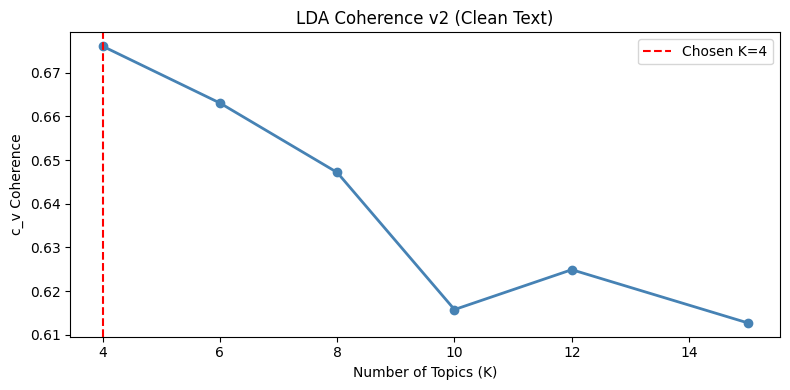

Using K=4


In [8]:
# ── Override K here if desired ──────────────────────────────────────────
# CHOSEN_K_LDA = 8

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(coherence_scores.keys()), list(coherence_scores.values()),
        'o-', color='steelblue', linewidth=2)
ax.axvline(CHOSEN_K_LDA, color='red', linestyle='--', label=f'Chosen K={CHOSEN_K_LDA}')
ax.set_xlabel('Number of Topics (K)')
ax.set_ylabel('c_v Coherence')
ax.set_title('LDA Coherence v2 (Clean Text)')
ax.legend()
plt.tight_layout()
plt.savefig('lda_coherence_v2.png', dpi=150)
plt.show()
print(f'Using K={CHOSEN_K_LDA}')


In [9]:
# ── Set K here and rerun from this cell down ──
CHOSEN_K_LDA = 6
print(f'LDA K set to {CHOSEN_K_LDA}')

LDA K set to 6


In [10]:
lda_final = lda_models[CHOSEN_K_LDA]

print(f'Top 12 words per topic  (K={CHOSEN_K_LDA})')
print('='*65)
for idx, topic in lda_final.print_topics(num_words=12):
    print(f'Topic {idx}: {topic}')
    print()


Top 12 words per topic  (K=6)
Topic 0: 0.014*"fake" + 0.014*"news" + 0.007*"like" + 0.007*"russia" + 0.007*"even" + 0.007*"never" + 0.007*"people" + 0.006*"media" + 0.006*"election" + 0.006*"nothing" + 0.006*"bad" + 0.005*"fbi"

Topic 1: 0.018*"biden" + 0.014*"country" + 0.013*"joe" + 0.010*"election" + 0.009*"democrats" + 0.008*"judge" + 0.008*"court" + 0.008*"left" + 0.007*"people" + 0.007*"radical" + 0.007*"case" + 0.007*"states"

Topic 2: 0.023*"united" + 0.021*"states" + 0.019*"great" + 0.012*"thank" + 0.008*"honor" + 0.007*"america" + 0.007*"border" + 0.007*"war" + 0.006*"world" + 0.006*"american" + 0.006*"white" + 0.006*"today"

Topic 3: 0.018*"great" + 0.018*"secure" + 0.018*"total" + 0.017*"complete" + 0.017*"endorsement" + 0.014*"district" + 0.014*"second" + 0.014*"amendment" + 0.013*"border" + 0.013*"military" + 0.012*"always" + 0.011*"congressman"

Topic 4: 0.020*"great" + 0.013*"america" + 0.011*"make" + 0.010*"country" + 0.010*"big" + 0.008*"people" + 0.007*"one" + 0.007*

In [11]:
print('Assigning dominant topic to each tweet...')
clean_df['lda_topic'] = [
    max(lda_final.get_document_topics(corpus[i], minimum_probability=0),
        key=lambda x: x[1])[0]
    for i in range(len(corpus))
]

print('LDA topic distribution:')
print(clean_df['lda_topic'].value_counts().sort_index())


Assigning dominant topic to each tweet...
LDA topic distribution:
lda_topic
0    6747
1    4913
2    3330
3    2140
4    6463
5    3034
Name: count, dtype: int64


## 4. PCA + K-means on FinBERT Embeddings (Clean Tweets Only)

Filter embeddings to cleaned tweets, then PCA 768→50, K-means over K ∈ {4,6,8,10,12,15}.

In [12]:
# Filter embeddings to clean tweets
clean_embed = embeddings[clean_df.index.values]
print(f'Clean embedding matrix: {clean_embed.shape}')

# PCA 768 → 50
scaler = StandardScaler()
E_scaled = scaler.fit_transform(clean_embed)
pca_50   = PCA(n_components=50, random_state=42)
E_50     = pca_50.fit_transform(E_scaled)
print(f'Variance explained by 50 PCs: {pca_50.explained_variance_ratio_.sum():.1%}')

# K-means grid
inertias   = {}
sil_scores = {}
km_models  = {}

print('\nFitting K-means over K =', K_RANGE)
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(E_50)
    inertias[k]   = km.inertia_
    sil_scores[k] = silhouette_score(E_50, labels, sample_size=5000, random_state=42)
    km_models[k]  = km
    print(f'  K={k:2d}  silhouette={sil_scores[k]:.4f}  inertia={inertias[k]:,.0f}')

CHOSEN_K_KM = max(sil_scores, key=sil_scores.get)
print(f'\nBest K by silhouette: {CHOSEN_K_KM}')
print('Override by setting CHOSEN_K_KM = <your value> in the next cell.')


Clean embedding matrix: (26627, 768)
Variance explained by 50 PCs: 80.6%

Fitting K-means over K = [4, 6, 8, 10, 12, 15]
  K= 4  silhouette=0.2239  inertia=9,819,468
  K= 6  silhouette=0.2069  inertia=8,638,695
  K= 8  silhouette=0.1785  inertia=7,944,588
  K=10  silhouette=0.1748  inertia=7,532,043
  K=12  silhouette=0.1652  inertia=7,231,948
  K=15  silhouette=0.1795  inertia=6,876,599

Best K by silhouette: 4
Override by setting CHOSEN_K_KM = <your value> in the next cell.


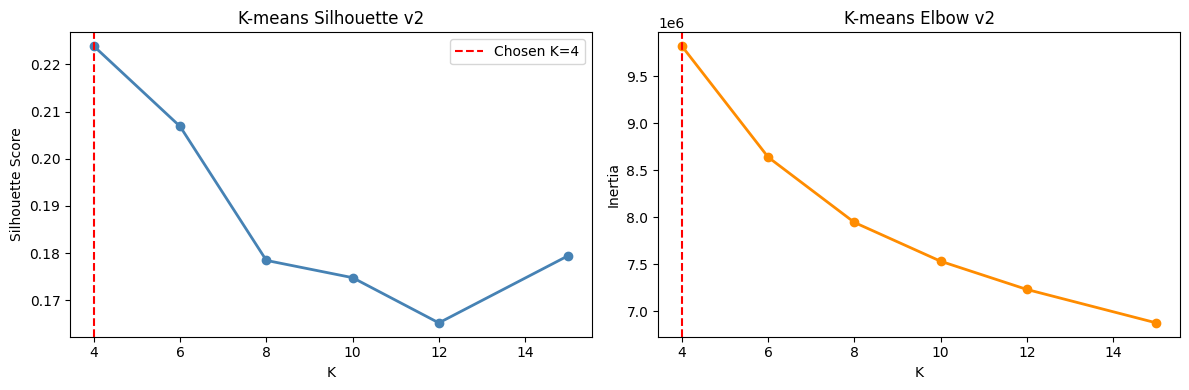

Using K=4


In [13]:
# ── Override K here if desired ──────────────────────────────────────────
# CHOSEN_K_KM = 8

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(sil_scores.keys()), list(sil_scores.values()), 'o-', color='steelblue', linewidth=2)
ax1.axvline(CHOSEN_K_KM, color='red', linestyle='--', label=f'Chosen K={CHOSEN_K_KM}')
ax1.set_xlabel('K'); ax1.set_ylabel('Silhouette Score')
ax1.set_title('K-means Silhouette v2'); ax1.legend()

ax2.plot(list(inertias.keys()), list(inertias.values()), 'o-', color='darkorange', linewidth=2)
ax2.axvline(CHOSEN_K_KM, color='red', linestyle='--')
ax2.set_xlabel('K'); ax2.set_ylabel('Inertia')
ax2.set_title('K-means Elbow v2')

plt.tight_layout()
plt.savefig('kmeans_selection_v2.png', dpi=150)
plt.show()
print(f'Using K={CHOSEN_K_KM}')


In [14]:
# ── Set K here and rerun from this cell down ──
CHOSEN_K_KM = 6
print(f'K-means K set to {CHOSEN_K_KM}')

K-means K set to 6


In [15]:
km_final = km_models[CHOSEN_K_KM]
clean_df['kmeans_cluster'] = km_final.labels_

print(f'K-means cluster distribution (K={CHOSEN_K_KM}):')
print(clean_df['kmeans_cluster'].value_counts().sort_index())

print('\nRepresentative tweets per cluster:')
print('='*70)
for c in range(CHOSEN_K_KM):
    mask  = clean_df['kmeans_cluster'] == c
    dists = np.linalg.norm(E_50[mask] - km_final.cluster_centers_[c], axis=1)
    top3  = clean_df[mask].iloc[np.argsort(dists)[:3]]['text_clean'].values
    print(f'\nCluster {c} ({mask.sum():,} tweets):')
    for t in top3:
        print(f'  • {t[:110]}')


K-means cluster distribution (K=6):
kmeans_cluster
0    3712
1    6173
2    4986
3    4751
4    2162
5    4843
Name: count, dtype: int64

Representative tweets per cluster:

Cluster 0 (3,712 tweets):
  • https:// truthsocial.com/@DC_Draino/115 118089050516091 . NEVER FELT BETTER IN MY LIFE. Also, DC IS A CRIME FR
  • Why won’t 60 Minutes release the fraudulent tapes of Lyin’ Kamala’s Interview with them? Could it be because i
  • THANK YOU TO ALL OF THE GREAT MEN AND WOMEN OF PENNSYLVANIA LAW ENFORCEMENT!

Cluster 1 (6,173 tweets):
  • Oh’ no, not Dan Bongino also? Not only Tucker, but Dan. What is going on at FoxNews?
  • Will be online tomorrow morning at 10:30am (Eastern) watching @jackngraham from @Prestonwood Baptist in Dallas
  • It was my great honor to visit with our HEROES last night at Walter Reed Medical Center. There is nobody like 

Cluster 2 (4,986 tweets):
  • Vote today for Dan Bishop. Will be great for North Carolina and our Country!
  • “Top Clinton adviser sent ‘top 

## 5. Compare LDA Topics vs K-means Clusters

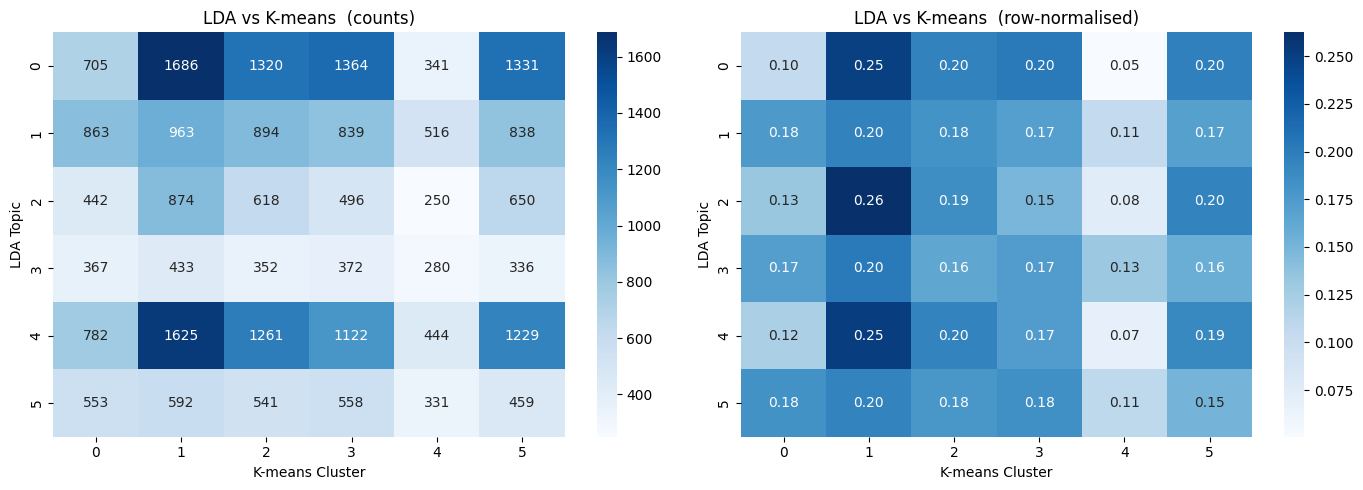

Adjusted Mutual Information: 0.0060
(0 = independent, 1 = perfectly aligned)


In [16]:
ct      = pd.crosstab(clean_df['lda_topic'], clean_df['kmeans_cluster'],
                     rownames=['LDA Topic'], colnames=['K-means Cluster'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ct,      annot=True, fmt='d',    cmap='Blues', ax=axes[0])
sns.heatmap(ct_norm, annot=True, fmt='.2f',  cmap='Blues', ax=axes[1])
axes[0].set_title('LDA vs K-means  (counts)')
axes[1].set_title('LDA vs K-means  (row-normalised)')
plt.tight_layout()
plt.savefig('topic_cluster_heatmap_v2.png', dpi=150)
plt.show()

ami = adjusted_mutual_info_score(clean_df['lda_topic'], clean_df['kmeans_cluster'])
print(f'Adjusted Mutual Information: {ami:.4f}')
print('(0 = independent, 1 = perfectly aligned)')


## 6. Temporal Analysis

In [17]:
clean_df['week_end'] = (
    clean_df['date']
    .dt.to_period('W-FRI')
    .apply(lambda p: p.end_time)
    .dt.tz_localize(None)
    .dt.normalize()
)

topic_dummies = pd.get_dummies(clean_df['lda_topic'], prefix='topic')
clean_df_t = pd.concat([clean_df[['week_end']], topic_dummies], axis=1)
weekly_topics = clean_df_t.groupby('week_end').mean().reset_index()

tp_vix = weekly_topics.merge(master[['week_end','vix']], on='week_end', how='inner')
topic_cols = [c for c in topic_dummies.columns]

corr_rows = []
for tc in topic_cols:
    tmp = tp_vix[[tc, 'vix']].dropna()
    r, p = stats.pearsonr(tmp[tc], tmp['vix'])
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    corr_rows.append({'Topic': tc, 'Pearson r': round(r, 3),
                      'p-value': round(p, 4), 'Sig': stars})

corr_df = pd.DataFrame(corr_rows).sort_values('Pearson r', key=abs, ascending=False)
print('Topic–VIX correlations:')
print(corr_df.to_string(index=False))


Topic–VIX correlations:
  Topic  Pearson r  p-value Sig
topic_2     -0.164   0.0010 ***
topic_3      0.092   0.0641    
topic_4      0.046   0.3547    
topic_0      0.038   0.4453    
topic_5      0.027   0.5880    
topic_1     -0.012   0.8163    


## 7. 5-Bucket VIX/EPU Labels & Export

Quintile bucketing (5 bins: VERY_LOW → VERY_HIGH) for finer GPT-2 conditioning.
Exports `tweet_labels_v2.csv`.

In [18]:
mc = master[['week_end','vix','epu']].dropna()

# Quintile cutoffs (4 cut points → 5 bins)
vix_cuts = mc['vix'].quantile([0.2, 0.4, 0.6, 0.8]).values
epu_cuts = mc['epu'].quantile([0.2, 0.4, 0.6, 0.8]).values

print(f'VIX quintile cutoffs: {vix_cuts.round(2)}')
print(f'EPU quintile cutoffs: {epu_cuts.round(2)}')

def bucket_5(val, cuts, prefix):
    if val <= cuts[0]: return f'{prefix}_VERY_LOW'
    if val <= cuts[1]: return f'{prefix}_LOW'
    if val <= cuts[2]: return f'{prefix}_MED'
    if val <= cuts[3]: return f'{prefix}_HIGH'
    return f'{prefix}_VERY_HIGH'

mc['vix_bucket'] = mc['vix'].apply(lambda v: bucket_5(v, vix_cuts, 'VIX'))
mc['epu_bucket'] = mc['epu'].apply(lambda e: bucket_5(e, epu_cuts, 'EPU'))

print('\nVIX bucket distribution:')
print(mc['vix_bucket'].value_counts().sort_index())
print('\nEPU bucket distribution:')
print(mc['epu_bucket'].value_counts().sort_index())


VIX quintile cutoffs: [12.63 14.91 17.54 22.66]
EPU quintile cutoffs: [108.21 124.94 149.97 218.06]

VIX bucket distribution:
vix_bucket
VIX_HIGH         80
VIX_LOW          82
VIX_MED          79
VIX_VERY_HIGH    81
VIX_VERY_LOW     81
Name: count, dtype: int64

EPU bucket distribution:
epu_bucket
EPU_HIGH         81
EPU_LOW          82
EPU_MED          79
EPU_VERY_HIGH    79
EPU_VERY_LOW     82
Name: count, dtype: int64


In [19]:
labels = clean_df[['tweet_idx','date','text_clean','week_end',
                   'lda_topic','kmeans_cluster','word_count']].copy()
labels = labels.rename(columns={'text_clean': 'text'})

labels = labels.merge(
    mc[['week_end','vix_bucket','epu_bucket','vix','epu']],
    on='week_end', how='left'
)
labels = labels.dropna(subset=['vix_bucket','epu_bucket'])

labels['gpt2_prompt'] = (
    '[' + labels['vix_bucket'] + '] ' +
    '[' + labels['epu_bucket'] + '] ' +
    '[TOPIC_' + labels['lda_topic'].astype(str) + '] ' +
    labels['text']
)

labels.to_csv('tweet_labels_v2.csv', index=False)

print(f'Saved tweet_labels_v2.csv — {len(labels):,} clean labeled tweets')
print(f'\nVIX buckets: {sorted(labels["vix_bucket"].unique())}')
print(f'EPU buckets: {sorted(labels["epu_bucket"].unique())}')
print(f'Topics:      {sorted(labels["lda_topic"].unique())}')
print(f'\nSample prompts:')
for p in labels['gpt2_prompt'].sample(5, random_state=42).values:
    print(f'  {p[:120]}')


Saved tweet_labels_v2.csv — 26,627 clean labeled tweets

VIX buckets: ['VIX_HIGH', 'VIX_LOW', 'VIX_MED', 'VIX_VERY_HIGH', 'VIX_VERY_LOW']
EPU buckets: ['EPU_HIGH', 'EPU_LOW', 'EPU_MED', 'EPU_VERY_HIGH', 'EPU_VERY_LOW']
Topics:      [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Sample prompts:
  [VIX_VERY_HIGH] [EPU_VERY_HIGH] [TOPIC_3] ...He is Strong on Crime, the Border, and Second Amendment. Mike has my Comple
  [VIX_HIGH] [EPU_LOW] [TOPIC_1] The TRUMP GAG ORDER that the CORRUPT Biden Administration is trying to obtain is totally 
  [VIX_LOW] [EPU_LOW] [TOPIC_2] Thank you! https:// thefederalist.com/2023/09/05/t hree-years-later-trump-deserves-a-nobel
  [VIX_LOW] [EPU_VERY_LOW] [TOPIC_1] “The Voting Machines Just ‘Failed’ In 18 States On Election Day!”
  [VIX_MED] [EPU_LOW] [TOPIC_0] “Nancy Pelosi and the Democrats can’t put down the Impeachment match. They know they could


In [20]:
import json

cutoffs_v2 = {
    'vix': vix_cuts.tolist(),
    'epu': epu_cuts.tolist(),
    'n_bins': 5,
    'labels': QUINTILE_LABELS
}
with open('bucket_cutoffs_v2.json', 'w') as f:
    json.dump(cutoffs_v2, f, indent=2)
print('Saved bucket_cutoffs_v2.json')
print(json.dumps(cutoffs_v2, indent=2))


Saved bucket_cutoffs_v2.json
{
  "vix": [
    12.634,
    14.91,
    17.538,
    22.656000000000002
  ],
  "epu": [
    108.21374,
    124.93665,
    149.9729,
    218.05829
  ],
  "n_bins": 5,
  "labels": [
    "VERY_LOW",
    "LOW",
    "MED",
    "HIGH",
    "VERY_HIGH"
  ]
}


## 8. Topic Word Summary — Name Your Topics

Top 15 words per LDA topic. Use these to assign human-readable names for the web app.

In [21]:
print(f'Top 15 words per topic (K={CHOSEN_K_LDA})')
print('='*70)
for idx, topic in lda_final.print_topics(num_words=15):
    words = [w.split('*')[1].strip().strip('"') for w in topic.split('+')]
    print(f'\nTopic {idx}:')
    print(f'  Words:  {" | ".join(words)}')
    print(f'  Count:  {(clean_df["lda_topic"] == idx).sum():,} tweets')
    # Show 3 representative tweets
    samples = clean_df[clean_df['lda_topic'] == idx]['text'].sample(3, random_state=42).values
    print(f'  Sample tweets:')
    for s in samples:
        print(f'    • {str(s)[:100]}')

print('\n' + '='*70)
print('Suggested topic names for app_v2.py — edit as needed:')
print('='*70)
topic_names = {i: f'Topic {i}' for i in range(CHOSEN_K_LDA)}
for i in range(CHOSEN_K_LDA):
    print(f'  {i}: "{topic_names[i]}"  <-- rename this')


Top 15 words per topic (K=6)

Topic 0:
  Words:  fake | news | like | russia | even | never | people | media | election | nothing | bad | fbi | many | time | one
  Count:  6,747 tweets
  Sample tweets:
    • ....that the House Democrats have done since she’s become Speaker, other than chase Donald Trump.” T
    • The Fake charges made by the highly partisan Unselect Committee of January 6th have already been sub
    • Why don’t the Unselects put up the many witnesses who are for our Country and fully agree that the E

Topic 1:
  Words:  biden | country | joe | election | democrats | judge | court | left | people | radical | case | states | crooked | never | america
  Count:  4,913 tweets
  Sample tweets:
    • “The Democrat Party hates America!” @marklevinshow https:// rumble.com/v2wfxsq-the-democra t-party-h
    • Congratulations to the Great People of Texas, and the State Senate, for rejecting POLITICAL PERSECUT
    • ....They are anti-Israel, pro Al-Qaeda, and comment on the 9/11 at

| Topic | Suggested Name | Key Words |
|---|---|---|
| 0 | **Fake News & Witch Hunt** | fake, news, russia, media, fbi, election |
| 1 | **Crooked Democrats** | biden, joe, democrats, judge, court, crooked, radical |
| 2 | **America First** | united states, honor, border, war, world, white house, peace |
| 3 | **MAGA Endorsements** | endorsement, congressman, district, second amendment, military |
| 4 | **Make America Great Again** | make, america, great, back, economy, stock market |
| 5 | **Rallies & Events** | donaldjtrump, maga, live, rumble, join, tonight, book |
